<a href="https://colab.research.google.com/github/Pratik872-bit/BMW-Car-Prize-Prediction/blob/main/BMW_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data=pd.read_csv('/content/drive/MyDrive/BMWdata.csv')
print(data)

          Model  Year         Region   Color Fuel_Type Transmission  \
0      5 Series  2016           Asia     Red    Petrol       Manual   
1            i8  2013  North America     Red    Hybrid    Automatic   
2      5 Series  2022  North America    Blue    Petrol    Automatic   
3            X3  2024    Middle East    Blue    Petrol    Automatic   
4      7 Series  2020  South America   Black    Diesel       Manual   
...         ...   ...            ...     ...       ...          ...   
49995        i3  2014           Asia     Red    Hybrid       Manual   
49996        i3  2023    Middle East  Silver  Electric       Manual   
49997  5 Series  2010    Middle East     Red    Petrol    Automatic   
49998        i3  2020           Asia   White  Electric    Automatic   
49999        X1  2020  North America    Blue    Diesel       Manual   

       Engine_Size_L  Mileage_KM  Price_USD  Sales_Volume Sales_Classification  
0                3.5      151748      98740          8300         

In [135]:
x=data.iloc[:,6:-3]
y=data.iloc[:,8:-2]
from sklearn.preprocessing import minmax_scale
x=minmax_scale(x)
y=minmax_scale(y)

# scaler=StandardScaler()
# x=scaler.fit_transform(x)
# y=scaler.fit_transform(y)

In [136]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [137]:
from tensorflow.keras.layers import Dropout
model=Sequential()
model.add(Dense(16,input_shape=(2,),activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(8,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='linear'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [138]:
model.compile(optimizer='adam',loss='mse',metrics=['mse'])


In [139]:
history=model.fit(
    x_train,y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1621 - mse: 0.1621 - val_loss: 0.0850 - val_mse: 0.0850
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0875 - mse: 0.0875 - val_loss: 0.0845 - val_mse: 0.0845
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0841 - mse: 0.0841 - val_loss: 0.0844 - val_mse: 0.0844
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0828 - mse: 0.0828 - val_loss: 0.0844 - val_mse: 0.0844
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0831 - mse: 0.0831 - val_loss: 0.0844 - val_mse: 0.0844
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0823 - mse: 0.0823 - val_loss: 0.0843 - val_mse: 0.0843
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0836 - mse: 0.0836 - val_loss: 0.0844 - val_mse: 0.0844
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0837 - mse: 0.0837 - val_loss: 0.0843 - val_mse: 0.0843
Epoch 9/10
1000/1000 ━━━━━━━━━━━━━━━━━━━

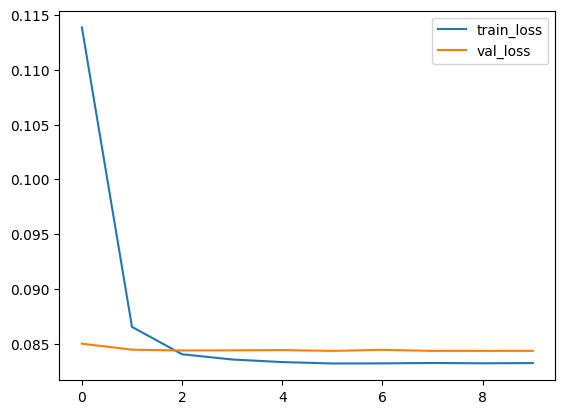

In [140]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.show()